Import Libraries

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [38]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

matches.head()

,id,Season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,IPL-2017,Hyderabad,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,IPL-2017,Pune,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,IPL-2017,Rajkot,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,IPL-2017,Indore,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,IPL-2017,Bangalore,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


Top Run Scorers

In [39]:
top_scorers = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

print(top_scorers)

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4632
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4446
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64


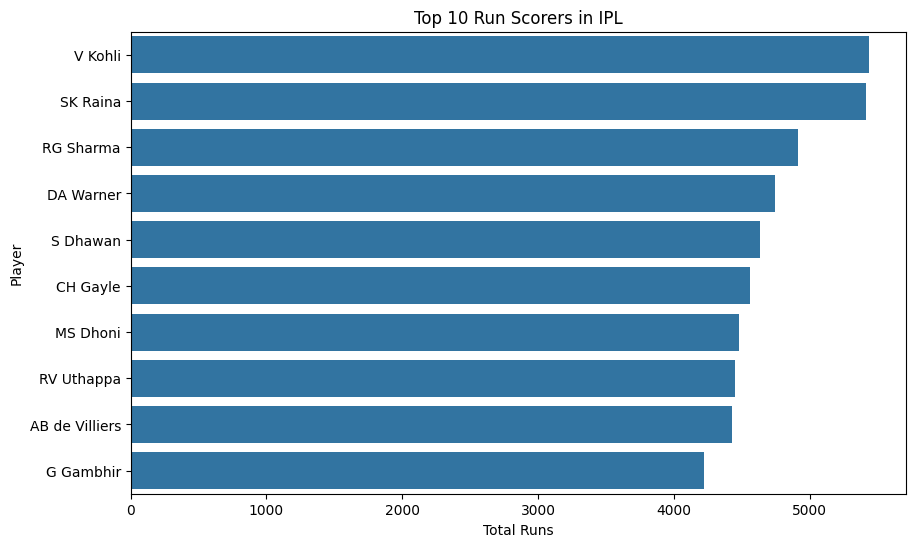

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(x=top_scorers.values, y=top_scorers.index)

plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Total Runs")
plt.ylabel("Player")

plt.show()

Player Strike Rate

In [41]:
player_stats = deliveries.groupby('batsman').agg(
    runs=('batsman_runs','sum'),
    balls=('ball','count')
)

player_stats['strike_rate'] = (player_stats['runs'] / player_stats['balls']) * 100

player_stats = player_stats.sort_values('strike_rate', ascending=False).head(10)

print(player_stats)

               runs  balls  strike_rate
batsman                                
B Stanlake        5      2   250.000000
Umar Gul         39     19   205.263158
RS Sodhi          4      2   200.000000
S Sharma          8      4   200.000000
AD Russell     1445    803   179.950187
Shahid Afridi    81     46   176.086957
I Malhotra        7      4   175.000000
S Curran         95     55   172.727273
K Gowtham       148     86   172.093023
SN Thakur        36     21   171.428571


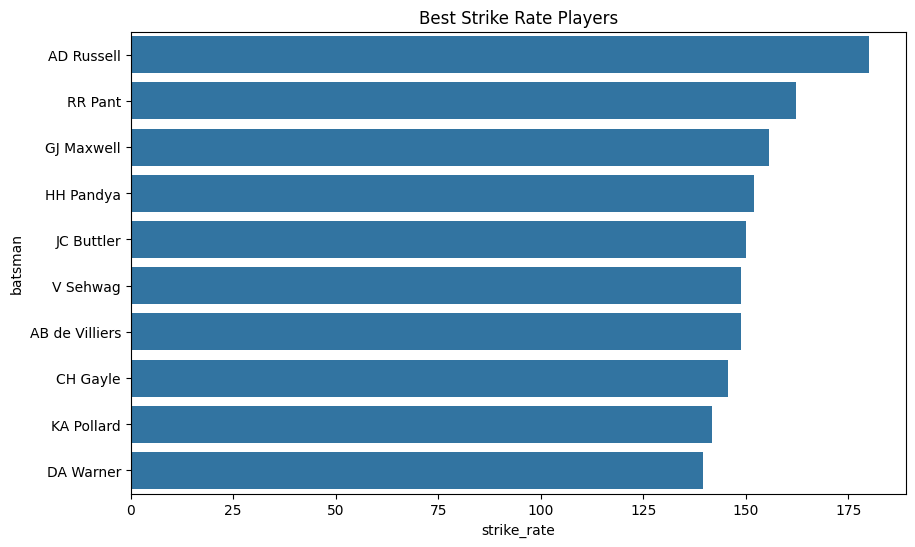

In [42]:
player_stats = deliveries.groupby('batsman').agg(
    runs=('batsman_runs','sum'),
    balls=('ball','count')
)

player_stats['strike_rate'] = (player_stats['runs'] / player_stats['balls']) * 100

top_strike = player_stats[player_stats['runs'] > 1000].sort_values('strike_rate', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_strike['strike_rate'], y=top_strike.index)

plt.title("Best Strike Rate Players")

plt.show()

Team Win Rates

In [44]:
team_matches = matches['team1'].value_counts() + matches['team2'].value_counts()

team_wins = matches['winner'].value_counts()

win_rate = (team_wins / team_matches) * 100

win_rate = win_rate.sort_values(ascending=False)

print(win_rate)

Delhi Capitals                 62.500000
Rising Pune Supergiant         62.500000
Chennai Super Kings            60.975610
Mumbai Indians                 58.288770
Sunrisers Hyderabad            53.703704
Kolkata Knight Riders          51.685393
Rajasthan Royals               51.020408
Royal Challengers Bangalore    46.666667
Kings XI Punjab                46.590909
Gujarat Lions                  43.333333
Kochi Tuskers Kerala           42.857143
Delhi Daredevils               41.614907
Deccan Chargers                38.666667
Rising Pune Supergiants        35.714286
Pune Warriors                  26.086957
Name: count, dtype: float64


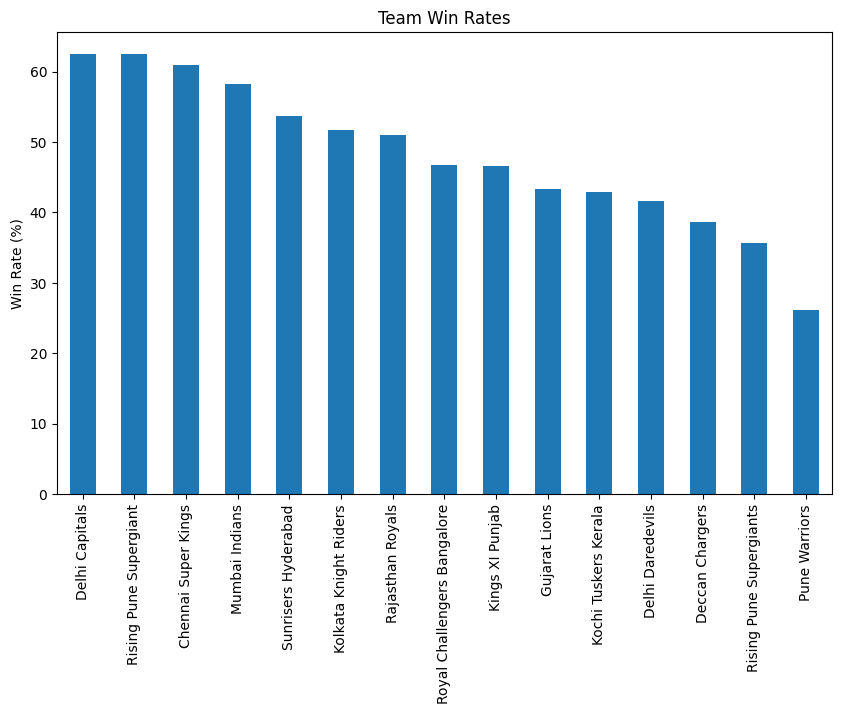

In [45]:
plt.figure(figsize=(10,6))

win_rate.plot(kind='bar')

plt.title("Team Win Rates")
plt.ylabel("Win Rate (%)")

plt.show()

In [46]:
toss_win_match_win = matches[matches['toss_winner'] == matches['winner']]

percentage = len(toss_win_match_win) / len(matches) * 100

print("Winning toss and match percentage:", percentage)

Winning toss and match percentage: 51.98412698412699


Runs Per Season

In [47]:
season_runs = matches.merge(deliveries, left_on='id', right_on='match_id')

season_runs = season_runs.groupby('Season')['batsman_runs'].sum()

print(season_runs)

Season
IPL-2008    16809
IPL-2009    15376
IPL-2010    17754
IPL-2011    19928
IPL-2012    21322
IPL-2013    21487
IPL-2014    17943
IPL-2015    17427
IPL-2016    17963
IPL-2017    17920
IPL-2018    19906
IPL-2019    19451
Name: batsman_runs, dtype: int64


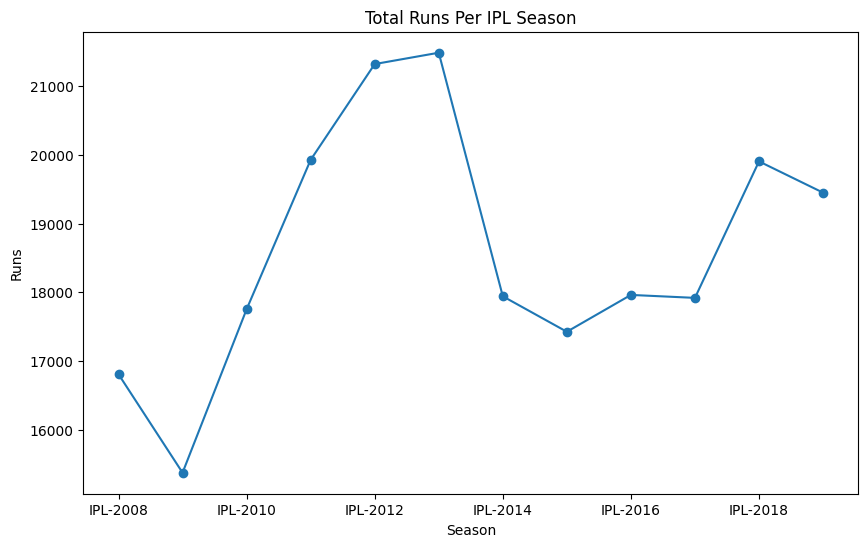

In [48]:
plt.figure(figsize=(10,6))

season_runs.plot(marker='o')

plt.title("Total Runs Per IPL Season")
plt.xlabel("Season")
plt.ylabel("Runs")

plt.show()

Player Performance Across Seasons

In [49]:
kohli = season_runs = matches.merge(deliveries, left_on='id', right_on='match_id')

kohli = kohli[kohli['batsman'] == "V Kohli"]

kohli_season = kohli.groupby('Season')['batsman_runs'].sum()

print(kohli_season)

Season
IPL-2008    165
IPL-2009    246
IPL-2010    307
IPL-2011    557
IPL-2012    364
IPL-2013    639
IPL-2014    359
IPL-2015    505
IPL-2016    973
IPL-2017    308
IPL-2018    539
IPL-2019    472
Name: batsman_runs, dtype: int64


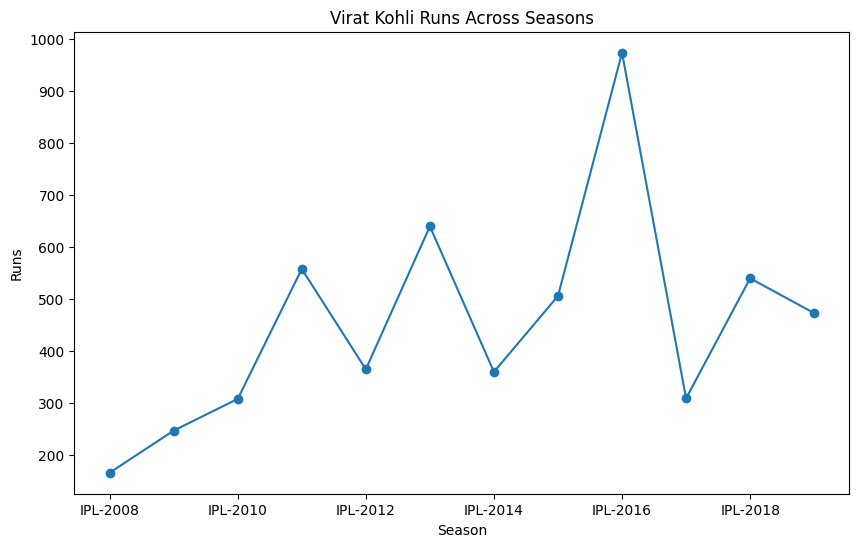

In [50]:
plt.figure(figsize=(10,6))

kohli_season.plot(marker='o')

plt.title("Virat Kohli Runs Across Seasons")
plt.xlabel("Season")
plt.ylabel("Runs")

plt.show()

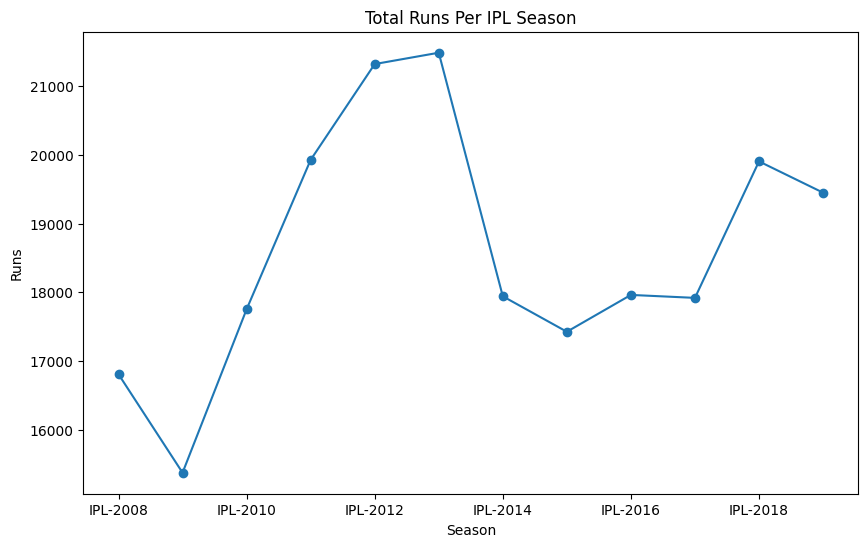

In [51]:
merged = matches.merge(deliveries, left_on='id', right_on='match_id')

season_runs = merged.groupby('Season')['batsman_runs'].sum()

plt.figure(figsize=(10,6))
season_runs.plot(marker='o')

plt.title("Total Runs Per IPL Season")
plt.xlabel("Season")
plt.ylabel("Runs")

plt.show()

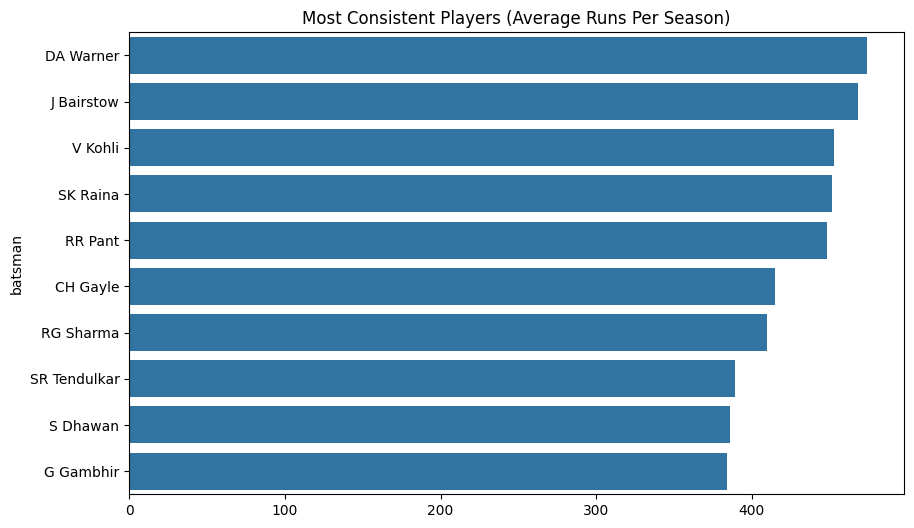

In [52]:
player_season = merged.groupby(['Season','batsman'])['batsman_runs'].sum().reset_index()

top_players = player_season.groupby('batsman')['batsman_runs'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_players.values, y=top_players.index)

plt.title("Most Consistent Players (Average Runs Per Season)")

plt.show()

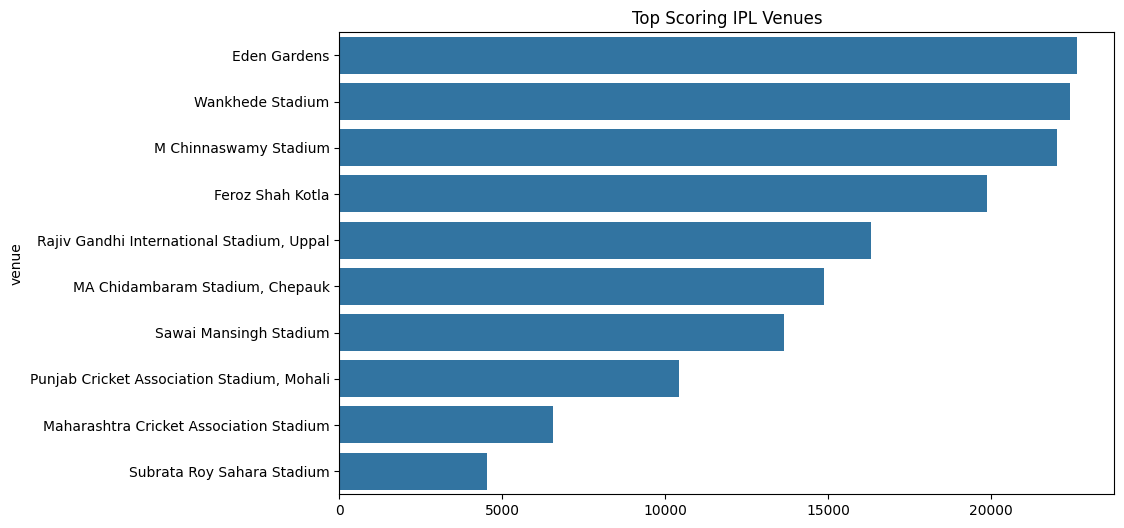

In [53]:
venue_runs = merged.groupby('venue')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=venue_runs.values, y=venue_runs.index)

plt.title("Top Scoring IPL Venues")

plt.show()

Top Wicket Takers

In [54]:
top_bowlers = deliveries[deliveries['dismissal_kind'].notna()]

top_bowlers = top_bowlers.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False).head(10)

print(top_bowlers)

bowler
SL Malinga         188
DJ Bravo           168
A Mishra           165
Harbhajan Singh    161
PP Chawla          156
B Kumar            141
R Ashwin           138
SP Narine          137
UT Yadav           136
R Vinay Kumar      127
Name: dismissal_kind, dtype: int64


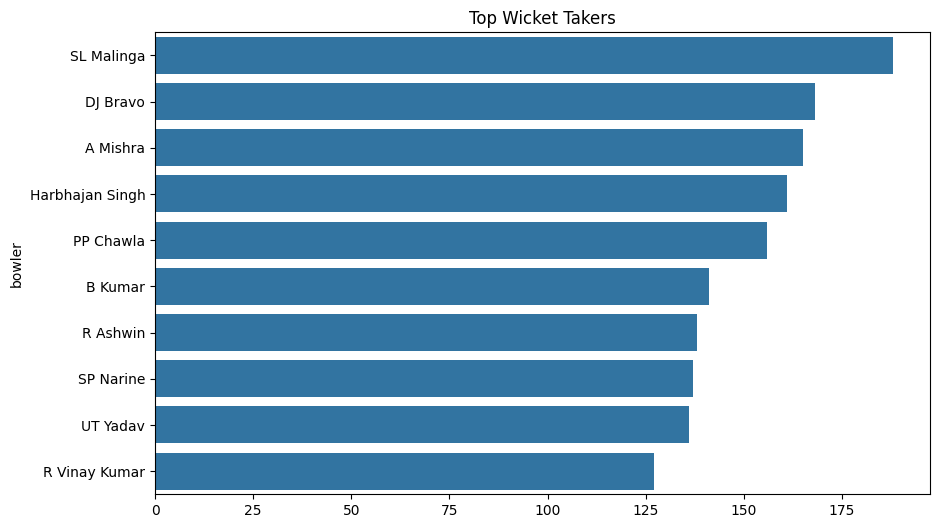

In [55]:
plt.figure(figsize=(10,6))

sns.barplot(x=top_bowlers.values, y=top_bowlers.index)

plt.title("Top Wicket Takers")

plt.show()

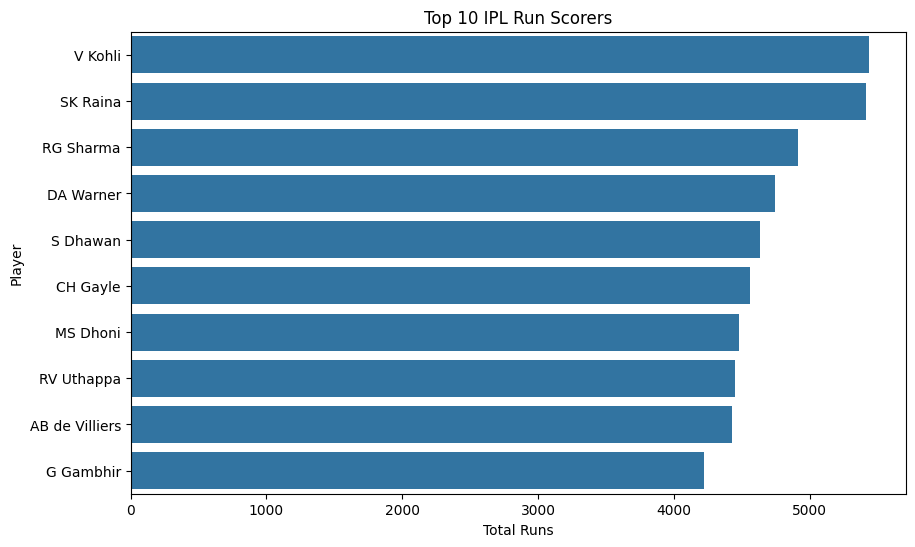

In [56]:
top_runs = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_runs.values, y=top_runs.index)

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Total Runs")
plt.ylabel("Player")

plt.show()

Correlation Heatmap

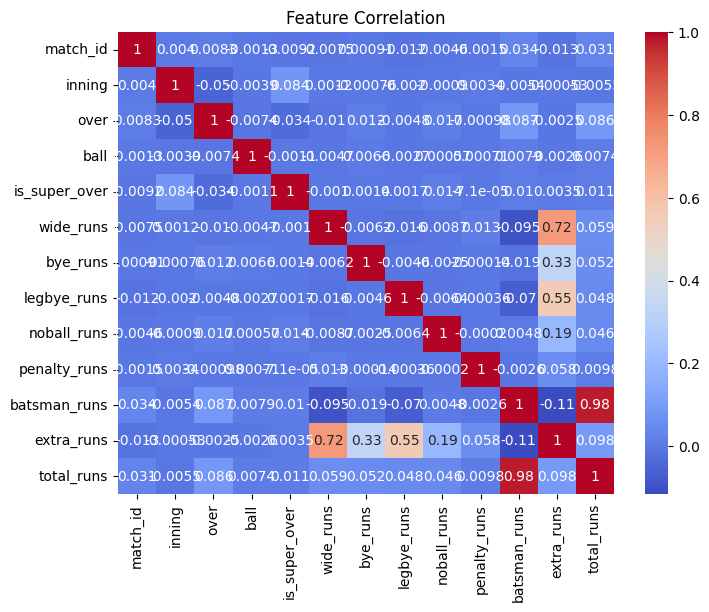

In [57]:
plt.figure(figsize=(8,6))

sns.heatmap(deliveries.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Feature Correlation")

plt.show()

Export Summary

In [58]:
summary = pd.DataFrame({
"Metric":[
"Top Run Scorer",
"Top Wicket Taker"
],
"Player":[
top_runs.index[0],
top_bowlers.index[0]
]
})

summary.to_csv("ipl_analysis_summary.csv", index=False)